# Notebook 09: MLP Baseline — Comparative Classifier Evaluation

## Purpose
Evaluate three classifier architectures on frozen `all-MiniLM-L6-v2` embeddings
using real training data only. This notebook establishes a clean non-VA baseline
for the augmentation experiments in Notebooks 10--12.

## Classifiers
| Classifier | Architecture | Parameters |
|---|---|---|
| Logistic Regression | Linear (384 → 2) | ~770 |
| MLP-1 | 384 → 256 → 2 | ~99K |
| MLP-2 | 384 → 256 → 128 → 2 | ~132K |

## Evaluation Pipeline
All three classifiers share an identical evaluation pipeline:
- `predict_proba` outputs used directly — no Venn-Abers calibration
- Decision threshold optimized on calibration set scores
- Final metrics reported on permanently locked test set
- No temperature scaling — uniform treatment across all classifiers

Dropping Venn-Abers is a deliberate choice here: MLP probability outputs
are poorly suited to isotonic regression calibration under extreme class
imbalance, producing unstable thresholds regardless of learning rate.
Threshold optimization on the calibration set provides a principled
alternative that is consistent across all three classifier types.

## Design Choices

**Loss function:** Cross-entropy with inverse class frequency weights —
consistent with all prior notebooks. Handles 100:1 imbalance without
oversampling or undersampling.

**Optimizer:** AdamW with weight decay 1e-4 — mild L2 regularization
to reduce overfitting on the small positive class.

**Learning rate:** 1e-3 for MLP — standard for small feedforward networks
on fixed-length input vectors. No encoder forward pass means no risk of
catastrophic forgetting.

**Early stopping:** On raw calibration set F1 (not calibrated) — VA is
absent so raw F1 on the cal set is the stopping criterion. Patience=5.

**Batch size:** 256 — large enough for stable gradient estimates on
frozen embeddings, small enough to run quickly on CPU.

## Outputs
- Metrics table: precision, recall, F1 for all three classifiers
- UMAP: training embeddings (all positives + 2,000 sampled negatives)
- DET curves: all three classifiers overlaid

## Relationship to Prior Notebooks
Prior notebooks (04--07) used frozen embeddings + LR + Venn-Abers.
This notebook replaces VA with threshold optimization and adds MLP
variants. Results are not directly comparable to VA-calibrated metrics
from prior notebooks — this is a new evaluation framework applied
consistently from Notebook 09 onward.

In [1]:
import numpy as np
import pandas as pd
import os
os.chdir("..")

UMAP plots -- Real Training Data Only

In [2]:
from sentence_transformers import SentenceTransformer
import umap
import matplotlib.pyplot as plt

# Load real data
train_df = pd.read_parquet("data/processed/train.parquet")
pos_df = train_df[train_df['label'] == 1]
neg_df = train_df[train_df['label'] == 0]

# Load saved embeddings
X_train = np.load("data/processed/embeddings/X_train.npy")
y_train = np.load("data/processed/embeddings/y_train.npy")

# Sample for visualization — all positives, 2000 random negatives
np.random.seed(42)
pos_idx = np.where(y_train == 1)[0]
neg_idx = np.where(y_train == 0)[0]
neg_sample_idx = np.random.choice(neg_idx, size=2000, replace=False)

X_umap_real = np.vstack([X_train[pos_idx], X_train[neg_sample_idx]])
labels_real = np.array(['Real Positive'] * len(pos_idx) +
                        ['Real Negative'] * len(neg_sample_idx))

print(f"Real positives: {len(pos_idx)}")
print(f"Real negatives (sampled): {len(neg_sample_idx)}")
print("Fitting UMAP...")

reducer_real = umap.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.1)
embedding_real = reducer_real.fit_transform(X_umap_real)
print("Done.")

c:\Users\vkamat01\hedging-txtclf-experiments\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Real positives: 674
Real negatives (sampled): 2000
Fitting UMAP...


c:\Users\vkamat01\hedging-txtclf-experiments\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Done.


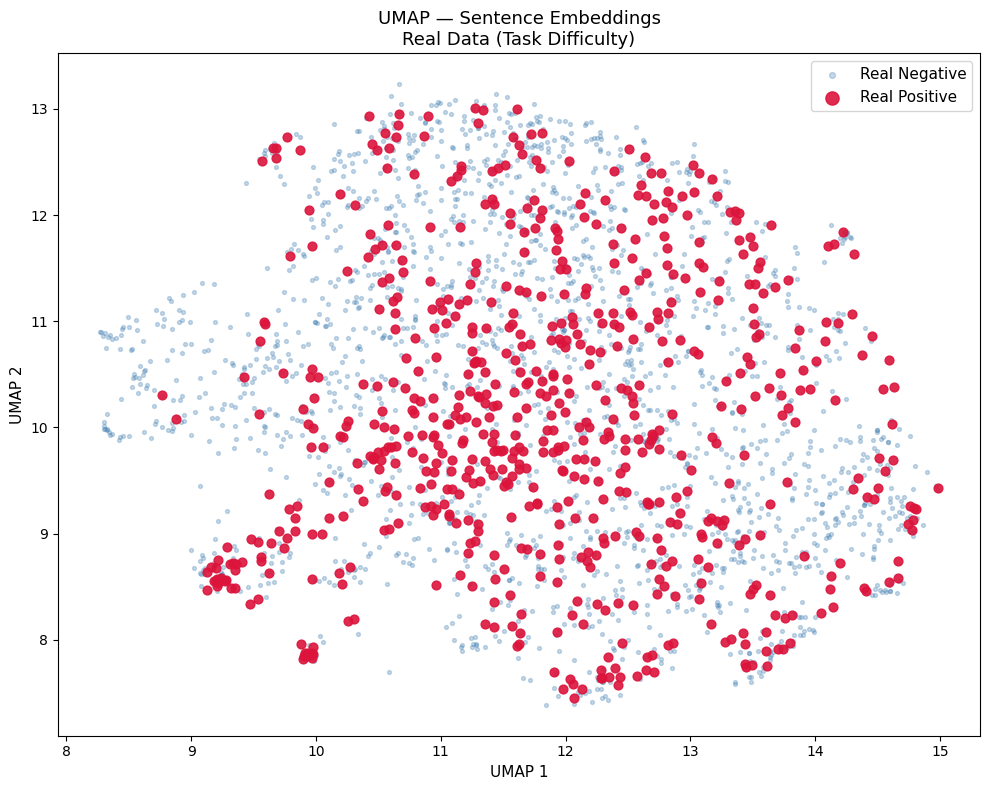

Saved.


In [3]:
color_map = {'Real Negative': 'steelblue', 'Real Positive': 'crimson'}
size_map = {'Real Negative': 8, 'Real Positive': 40}
alpha_map = {'Real Negative': 0.3, 'Real Positive': 0.9}

fig, ax = plt.subplots(figsize=(10, 8))

for label in ['Real Negative', 'Real Positive']:
    mask = labels_real == label
    ax.scatter(embedding_real[mask, 0], embedding_real[mask, 1],
               c=color_map[label], s=size_map[label],
               alpha=alpha_map[label], label=label)

ax.set_title('UMAP — Sentence Embeddings\nReal Data (Task Difficulty)',
             fontsize=13)
ax.legend(fontsize=11, markerscale=1.5)
ax.set_xlabel('UMAP 1', fontsize=11)
ax.set_ylabel('UMAP 2', fontsize=11)
plt.tight_layout()
plt.savefig("data/results/umap_real_only.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [4]:
# -----------------------------------------------
# ML and PyTorch imports
# -----------------------------------------------

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import AdamW

from sklearn.linear_model import LogisticRegression
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import (
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    det_curve,
)

import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cpu")
print(f"PyTorch: {torch.__version__} | Device: {DEVICE}")

PyTorch: 2.10.0+cpu | Device: cpu


In [5]:
# -----------------------------------------------
# Load cal and test embeddings and labels
# X_train and y_train already loaded for UMAP above
# -----------------------------------------------
X_cal  = np.load("data/processed/embeddings/X_cal.npy")
y_cal  = np.load("data/processed/embeddings/y_cal.npy")
X_test = np.load("data/processed/embeddings/X_test.npy")
y_test = np.load("data/processed/embeddings/y_test.npy")

print(f"Train: {X_train.shape} | Positives: {y_train.sum()}")
print(f"Cal:   {X_cal.shape}   | Positives: {y_cal.sum()}")
print(f"Test:  {X_test.shape}  | Positives: {y_test.sum()}")

# -----------------------------------------------
# Threshold utility
# Always optimized on cal set, applied to test set
# -----------------------------------------------
def optimal_threshold_f1(
    y_true: np.ndarray,
    y_scores: np.ndarray,
    thresholds: np.ndarray = np.arange(0.01, 0.70, 0.01),
) -> tuple:
    best_f1, best_t = 0, 0.5
    for t in thresholds:
        preds = (y_scores >= t).astype(int)
        f1 = f1_score(y_true, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    return best_t, best_f1

Train: (69510, 384) | Positives: 674
Cal:   (9931, 384)   | Positives: 96
Test:  (19861, 384)  | Positives: 192


In [6]:
# -----------------------------------------------
# MLP architecture
# hidden_dims controls depth and width:
#   [256]      -> 384 -> 256 -> 2  (MLP-1)
#   [256, 128] -> 384 -> 256 -> 128 -> 2  (MLP-2)
# Each hidden layer is followed by ReLU and Dropout.
# -----------------------------------------------
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 384,
        hidden_dims: list = [256],
        dropout: float = 0.1,
    ):
        super().__init__()
        layers = []
        in_dim = input_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(in_dim, h_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            in_dim = h_dim
        layers.append(nn.Linear(in_dim, 2))  # binary output
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


# -----------------------------------------------
# Sklearn-compatible wrapper
# Needed so MLP plugs into the same evaluation
# pipeline as LogisticRegression.
# fit() trains the MLP with early stopping on
# raw cal F1 if X_cal and y_cal are provided.
# predict_proba() returns softmax probabilities.
# -----------------------------------------------
class MLPClassifier(BaseEstimator, ClassifierMixin):
    def __init__(
        self,
        hidden_dims: list = [256],
        n_epochs: int = 50,
        lr: float = 1e-3,
        batch_size: int = 256,
        patience: int = 5,
        dropout: float = 0.1,
        random_state: int = SEED,
    ):
        self.hidden_dims   = hidden_dims
        self.n_epochs      = n_epochs
        self.lr            = lr
        self.batch_size    = batch_size
        self.patience      = patience
        self.dropout       = dropout
        self.random_state  = random_state
        self.classes_      = np.array([0, 1])

    def fit(self, X, y, X_cal=None, y_cal=None):
        torch.manual_seed(self.random_state)

        # Inverse class frequency weights — handles 100:1 imbalance
        n_neg, n_pos = (y == 0).sum(), (y == 1).sum()
        class_weights = torch.tensor([1.0 / n_neg, 1.0 / n_pos], dtype=torch.float)
        criterion = nn.CrossEntropyLoss(weight=class_weights)

        self.model_ = MLP(
            input_dim=X.shape[1],
            hidden_dims=self.hidden_dims,
            dropout=self.dropout,
        )
        optimizer = AdamW(
            self.model_.parameters(),
            lr=self.lr,
            weight_decay=1e-4,
        )

        # DataLoader — shuffle each epoch for stable gradient estimates
        loader = DataLoader(
            TensorDataset(
                torch.tensor(X, dtype=torch.float),
                torch.tensor(y, dtype=torch.long),
            ),
            batch_size=self.batch_size,
            shuffle=True,
        )

        best_cal_f1  = 0.0
        best_weights = None
        no_improve   = 0

        for epoch in range(self.n_epochs):
            self.model_.train()
            for X_batch, y_batch in loader:
                optimizer.zero_grad()
                loss = criterion(self.model_(X_batch), y_batch)
                loss.backward()
                optimizer.step()

            # Early stopping on raw cal F1 if cal data provided
            if X_cal is not None and y_cal is not None:
                cal_scores = self.predict_proba(X_cal)[:, 1]
                _, cal_f1  = optimal_threshold_f1(y_cal, cal_scores)
                if cal_f1 > best_cal_f1:
                    best_cal_f1  = cal_f1
                    best_weights = {k: v.clone() for k, v in self.model_.state_dict().items()}
                    no_improve   = 0
                else:
                    no_improve += 1
                    if no_improve >= self.patience:
                        print(f"  Early stopping at epoch {epoch+1} "
                              f"(best cal F1: {best_cal_f1:.4f})")
                        break

        if best_weights is not None:
            self.model_.load_state_dict(best_weights)

        return self

    def predict_proba(self, X):
        self.model_.eval()
        with torch.no_grad():
            probs = torch.softmax(
                self.model_(torch.tensor(X, dtype=torch.float)), dim=1
            ).numpy()
        return probs

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


print("MLP class and MLPClassifier wrapper defined.")
print(f"MLP-1 params: {sum(p.numel() for p in MLP(hidden_dims=[256]).parameters()):,}")
print(f"MLP-2 params: {sum(p.numel() for p in MLP(hidden_dims=[256,128]).parameters()):,}")

MLP class and MLPClassifier wrapper defined.
MLP-1 params: 99,074
MLP-2 params: 131,714


In [7]:
# -----------------------------------------------
# Unified evaluation function
# Works for LR, MLP-1, and MLP-2 via the same
# predict_proba interface. Threshold optimized
# on cal set, metrics reported on test set.
# -----------------------------------------------
def evaluate_classifier(
    clf,
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_cal: np.ndarray,
    y_cal: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    name: str = "Classifier",
) -> dict:
    """
    Train classifier, optimize threshold on cal set,
    evaluate on test set. Returns metrics dict.
    """
    # Train — pass cal data for MLP early stopping
    # LR ignores extra kwargs, MLP uses them
    if isinstance(clf, MLPClassifier):
        clf.fit(X_train, y_train, X_cal=X_cal, y_cal=y_cal)
    else:
        clf.fit(X_train, y_train)

    # Scores on cal set for threshold optimization
    cal_scores  = clf.predict_proba(X_cal)[:, 1]
    t, cal_f1   = optimal_threshold_f1(y_cal, cal_scores)

    # Scores on test set — threshold fixed from cal
    test_scores = clf.predict_proba(X_test)[:, 1]
    y_pred      = (test_scores >= t).astype(int)

    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)

    print(f"\n=== {name} (threshold={t:.2f}) ===")
    print(classification_report(y_test, y_pred, digits=3))

    return {
        'name':        name,
        'clf':         clf,
        'threshold':   t,
        'cal_f1':      cal_f1,
        'test_scores': test_scores,
        'y_pred':      y_pred,
        'precision':   prec,
        'recall':      rec,
        'f1':          f1,
    }

print("evaluate_classifier() defined.")

evaluate_classifier() defined.


In [8]:
# -----------------------------------------------
# Run all three classifiers
# Change hidden_dims to switch MLP architecture
# LR is the linear baseline for comparison
# -----------------------------------------------

results = {}

# --- Logistic Regression ---
print("Training LR...")
results['LR'] = evaluate_classifier(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED),
    X_train, y_train, X_cal, y_cal, X_test, y_test,
    name="Logistic Regression",
)

# --- MLP-1: single hidden layer ---
print("\nTraining MLP-1...")
results['MLP-1'] = evaluate_classifier(
    MLPClassifier(hidden_dims=[256], random_state=SEED),
    X_train, y_train, X_cal, y_cal, X_test, y_test,
    name="MLP-1 (384→256→2)",
)

# --- MLP-2: two hidden layers ---
print("\nTraining MLP-2...")
results['MLP-2'] = evaluate_classifier(
    MLPClassifier(hidden_dims=[256, 128], random_state=SEED),
    X_train, y_train, X_cal, y_cal, X_test, y_test,
    name="MLP-2 (384→256→128→2)",
)

Training LR...

=== Logistic Regression (threshold=0.69) ===
              precision    recall  f1-score   support

           0      0.997     0.923     0.959     19669
           1      0.085     0.729     0.152       192

    accuracy                          0.921     19861
   macro avg      0.541     0.826     0.555     19861
weighted avg      0.988     0.921     0.951     19861


Training MLP-1...
  Early stopping at epoch 25 (best cal F1: 0.2541)

=== MLP-1 (384→256→2) (threshold=0.69) ===
              precision    recall  f1-score   support

           0      0.995     0.981     0.988     19669
           1      0.190     0.464     0.270       192

    accuracy                          0.976     19861
   macro avg      0.592     0.722     0.629     19861
weighted avg      0.987     0.976     0.981     19861


Training MLP-2...
  Early stopping at epoch 22 (best cal F1: 0.2266)

=== MLP-2 (384→256→128→2) (threshold=0.69) ===
              precision    recall  f1-score   support

In [9]:
# Verify thresholds were computed independently
for name, r in results.items():
    cal_scores = r['clf'].predict_proba(X_cal)[:, 1]
    t, f1 = optimal_threshold_f1(y_cal, cal_scores)
    print(f"{name}: threshold={t:.2f} | cal F1={f1:.4f} | "
          f"score mean={cal_scores.mean():.3f} | "
          f"score std={cal_scores.std():.3f}")

LR: threshold=0.69 | cal F1=0.1515 | score mean=0.184 | score std=0.256
MLP-1: threshold=0.69 | cal F1=0.2541 | score mean=0.047 | score std=0.154
MLP-2: threshold=0.69 | cal F1=0.2266 | score mean=0.042 | score std=0.172


Classifier                 Precision   Recall       F1  Threshold
-----------------------------------------------------------------
Logistic Regression            0.085    0.729    0.152       0.69
MLP-1 (384→256→2)              0.190    0.464    0.270       0.69
MLP-2 (384→256→128→2)          0.134    0.448    0.207       0.69


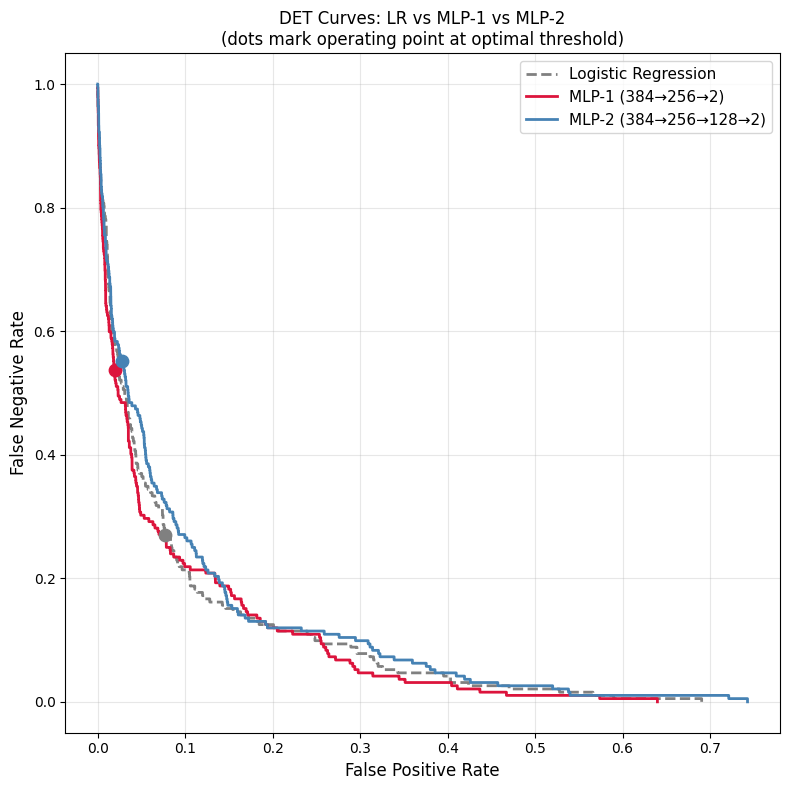

DET curves saved.


In [10]:
# -----------------------------------------------
# Summary table
# -----------------------------------------------
print("=" * 65)
print(f"{'Classifier':<25} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Threshold':>10}")
print("-" * 65)
for name, r in results.items():
    print(f"{r['name']:<25} {r['precision']:>10.3f} {r['recall']:>8.3f} "
          f"{r['f1']:>8.3f} {r['threshold']:>10.2f}")
print("=" * 65)

# -----------------------------------------------
# DET curves — all three classifiers overlaid
# Lower and further left = better
# -----------------------------------------------
fig, ax = plt.subplots(figsize=(8, 8))

colors = {'LR': 'gray', 'MLP-1': 'crimson', 'MLP-2': 'steelblue'}
styles = {'LR': '--', 'MLP-1': '-', 'MLP-2': '-'}

for key, r in results.items():
    fpr, fnr, _ = det_curve(y_test, r['test_scores'])
    ax.plot(fpr, fnr,
            color=colors[key],
            linestyle=styles[key],
            linewidth=2,
            label=r['name'])

    # Mark operating point at chosen threshold
    t = r['threshold']
    scores = r['test_scores']
    preds  = (scores >= t).astype(int)
    fp = ((preds == 1) & (y_test == 0)).sum() / (y_test == 0).sum()
    fn = ((preds == 0) & (y_test == 1)).sum() / (y_test == 1).sum()
    ax.scatter(fp, fn, color=colors[key], s=80, zorder=5)

ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("False Negative Rate", fontsize=12)
ax.set_title("DET Curves: LR vs MLP-1 vs MLP-2\n(dots mark operating point at optimal threshold)", fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("data/results/det_curves_09.png", dpi=150, bbox_inches='tight')
plt.show()
print("DET curves saved.")

In [11]:
# -----------------------------------------------
# Save metrics for comparison in Notebooks 10-12
# -----------------------------------------------
import json

metrics_09 = {
    name: {
        'precision': round(r['precision'], 4),
        'recall':    round(r['recall'], 4),
        'f1':        round(r['f1'], 4),
        'threshold': round(r['threshold'], 4),
        'cal_f1':    round(r['cal_f1'], 4),
    }
    for name, r in results.items()
}

os.makedirs("data/results", exist_ok=True)
with open("data/results/metrics_09_baseline.json", "w") as f:
    json.dump(metrics_09, f, indent=2)

print("Metrics saved to data/results/metrics_09_baseline.json")
print(json.dumps(metrics_09, indent=2))

Metrics saved to data/results/metrics_09_baseline.json
{
  "LR": {
    "precision": 0.0846,
    "recall": 0.7292,
    "f1": 0.1516,
    "threshold": 0.69,
    "cal_f1": 0.1515
  },
  "MLP-1": {
    "precision": 0.1902,
    "recall": 0.4635,
    "f1": 0.2697,
    "threshold": 0.69,
    "cal_f1": 0.2541
  },
  "MLP-2": {
    "precision": 0.1344,
    "recall": 0.4479,
    "f1": 0.2067,
    "threshold": 0.69,
    "cal_f1": 0.2266
  }
}


In [12]:
# -----------------------------------------------
# Save Notebook 09 classifier artifacts
# LR saved as pickle, MLP-1 and MLP-2 as .pt files
# Reloaded in Notebooks 10-12 for filtering and comparison
# -----------------------------------------------
import pickle

os.makedirs("data/results/classifiers", exist_ok=True)

# Save LR
with open("data/results/classifiers/lr_09.pkl", "wb") as f:
    pickle.dump(results['LR']['clf'], f)
print("LR saved.")

# Save MLP-1 weights
torch.save(
    results['MLP-1']['clf'].model_.state_dict(),
    "data/results/classifiers/mlp1_09.pt"
)
print("MLP-1 weights saved.")

# Save MLP-2 weights
torch.save(
    results['MLP-2']['clf'].model_.state_dict(),
    "data/results/classifiers/mlp2_09.pt"
)
print("MLP-2 weights saved.")

print("\nAll classifiers saved to data/results/classifiers/")

LR saved.
MLP-1 weights saved.
MLP-2 weights saved.

All classifiers saved to data/results/classifiers/
